In [ ]:
import pandas as pd

df = pd.read_pickle("all_sys_config_10s_1s.pkl")

df.shape

(355968, 111)

In [ ]:
df.head()

,start,end,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,...,mem_exec_avg_gpa_jump,mem_exec_max_gpa_jump,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,mem_exec_gpa_range,is_ransomware,operation,execution_id,execution_log_cnt,sys_config
0,0 days 00:00:00,0 days 00:00:10,7651840.0,3704422.4,5.503250e+14,7.344057e+14,0.833415,0.010552,0.839345,11.0,...,3.844968e+09,1.927498e+10,1.0,0.988889,1.954823e+10,False,AESCrypt,AESCrypt-20240228_12-09-05,9,extra_i3-gen12_ddr5-4800-16g
1,0 days 00:00:01,0 days 00:00:11,8012288.0,4490444.8,5.571908e+14,1.368933e+15,0.838371,0.009608,0.849257,11.0,...,4.403774e+09,1.281490e+10,1.0,0.947368,1.954823e+10,False,AESCrypt,AESCrypt-20240228_12-09-05,9,extra_i3-gen12_ddr5-4800-16g
2,0 days 00:00:02,0 days 00:00:12,9801420.8,4525670.4,5.137275e+14,1.382114e+15,0.838417,0.009030,0.932870,12.0,...,3.756318e+09,7.914538e+09,1.0,1.000000,7.914702e+09,False,AESCrypt,AESCrypt-20240228_12-09-05,9,extra_i3-gen12_ddr5-4800-16g
3,0 days 00:00:03,0 days 00:00:13,10182348.8,5762252.8,2.625399e+14,1.749897e+15,0.856967,0.024508,0.870674,10.0,...,3.756318e+09,7.914538e+09,1.0,1.000000,7.914702e+09,False,AESCrypt,AESCrypt-20240228_12-09-05,9,extra_i3-gen12_ddr5-4800-16g
4,0 days 00:00:04,0 days 00:00:14,11675648.0,6299289.6,2.446092e+14,1.804892e+15,0.869772,0.028997,0.870674,10.0,...,3.756318e+09,7.914538e+09,1.0,1.000000,7.914702e+09,False,AESCrypt,AESCrypt-20240228_12-09-05,9,extra_i3-gen12_ddr5-4800-16g


In [ ]:
mix_df = df[df['sys_config'].str.contains('mix', case=False, na=False)].copy()
mix_df.shape

(18003, 111)

In [ ]:
mix_df.head()

,start,end,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,...,mem_exec_avg_gpa_jump,mem_exec_max_gpa_jump,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,mem_exec_gpa_range,is_ransomware,operation,execution_id,execution_log_cnt,sys_config
67754,0 days 00:00:00,0 days 00:00:10,7034572.8,23591526.4,7.961911e+14,1.961102e+15,0.911601,0.013835,0.773299,22.0,...,5.256816e+09,1.933745e+10,1.0,0.942308,1.956838e+10,False,AESCrypt_Conti,AESCrypt_Conti-20240301_00-25-27,4,mix_i3-gen12_ddr4-2133-16g
67755,0 days 00:00:01,0 days 00:00:11,7386777.6,23465164.8,8.372382e+14,1.990424e+15,0.915454,0.009423,0.716349,13.0,...,6.911273e+09,1.459808e+10,1.0,0.571429,1.937232e+10,False,AESCrypt_Conti,AESCrypt_Conti-20240301_00-25-27,4,mix_i3-gen12_ddr4-2133-16g
67756,0 days 00:00:02,0 days 00:00:12,6890240.0,19321241.6,9.440838e+14,2.390712e+15,0.899958,0.007719,0.776013,1.0,...,6.627474e+09,1.415770e+10,1.0,0.666667,1.897966e+10,False,AESCrypt_Conti,AESCrypt_Conti-20240301_00-25-27,4,mix_i3-gen12_ddr4-2133-16g
67757,0 days 00:00:03,0 days 00:00:13,6363289.6,16987443.2,9.539523e+14,2.494182e+15,0.889304,0.007817,0.745246,1.0,...,2.711893e+09,5.423779e+09,1.0,1.000000,5.423779e+09,False,AESCrypt_Conti,AESCrypt_Conti-20240301_00-25-27,4,mix_i3-gen12_ddr4-2133-16g
67758,0 days 00:00:04,0 days 00:00:14,5798195.2,16033638.4,9.371136e+14,2.474516e+15,0.875480,0.007566,0.745246,1.0,...,3.554099e+09,5.423779e+09,1.0,2.000000,5.423779e+09,False,AESCrypt_Conti,AESCrypt_Conti-20240301_00-25-27,4,mix_i3-gen12_ddr4-2133-16g


In [ ]:
uniq_ops = mix_df['operation'].unique()

In [ ]:
mix_df.isna().sum().sum()

np.int64(44625)

In [ ]:
mix_df = mix_df.fillna(0)

In [ ]:
mix_df.isna().sum().sum()

np.int64(0)

In [ ]:
num_cols = mix_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = mix_df.select_dtypes(include=['object']).columns.tolist()

In [ ]:
mix_df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
avg_ata_read,18003.0,1.231670e+07,1.063380e+07,0.0,6.569984e+06,9.938995e+06,1.455639e+07,1.952257e+08
avg_ata_write,18003.0,1.689368e+07,1.577238e+07,0.0,7.342387e+06,1.191332e+07,2.163796e+07,1.262376e+08
lba_read_var,18003.0,8.273732e+14,4.939187e+14,0.0,5.170392e+14,6.954303e+14,9.675761e+14,3.855762e+15
lba_write_var,18003.0,1.600837e+15,8.455912e+14,0.0,8.768002e+14,1.409772e+15,2.292059e+15,4.361930e+15
avg_storage_entropy,18003.0,6.747472e-01,2.354229e-01,0.0,4.203425e-01,7.590730e-01,8.722547e-01,9.919405e-01
...,...,...,...,...,...,...,...,...
mem_exec_max_gpa_jump,18003.0,9.417555e+08,3.099756e+09,0.0,0.000000e+00,0.000000e+00,1.096752e+07,1.955836e+10
mem_exec_access_locality,18003.0,4.653323e-01,4.914595e-01,0.0,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
mem_exec_frwrd_bckwrd_ratio,18003.0,1.595290e+09,5.445304e+09,0.0,1.000000e+00,1.000000e+00,1.000000e+00,1.100000e+11
mem_exec_gpa_range,18003.0,9.793476e+08,3.236909e+09,0.0,0.000000e+00,0.000000e+00,1.225042e+07,1.958565e+10


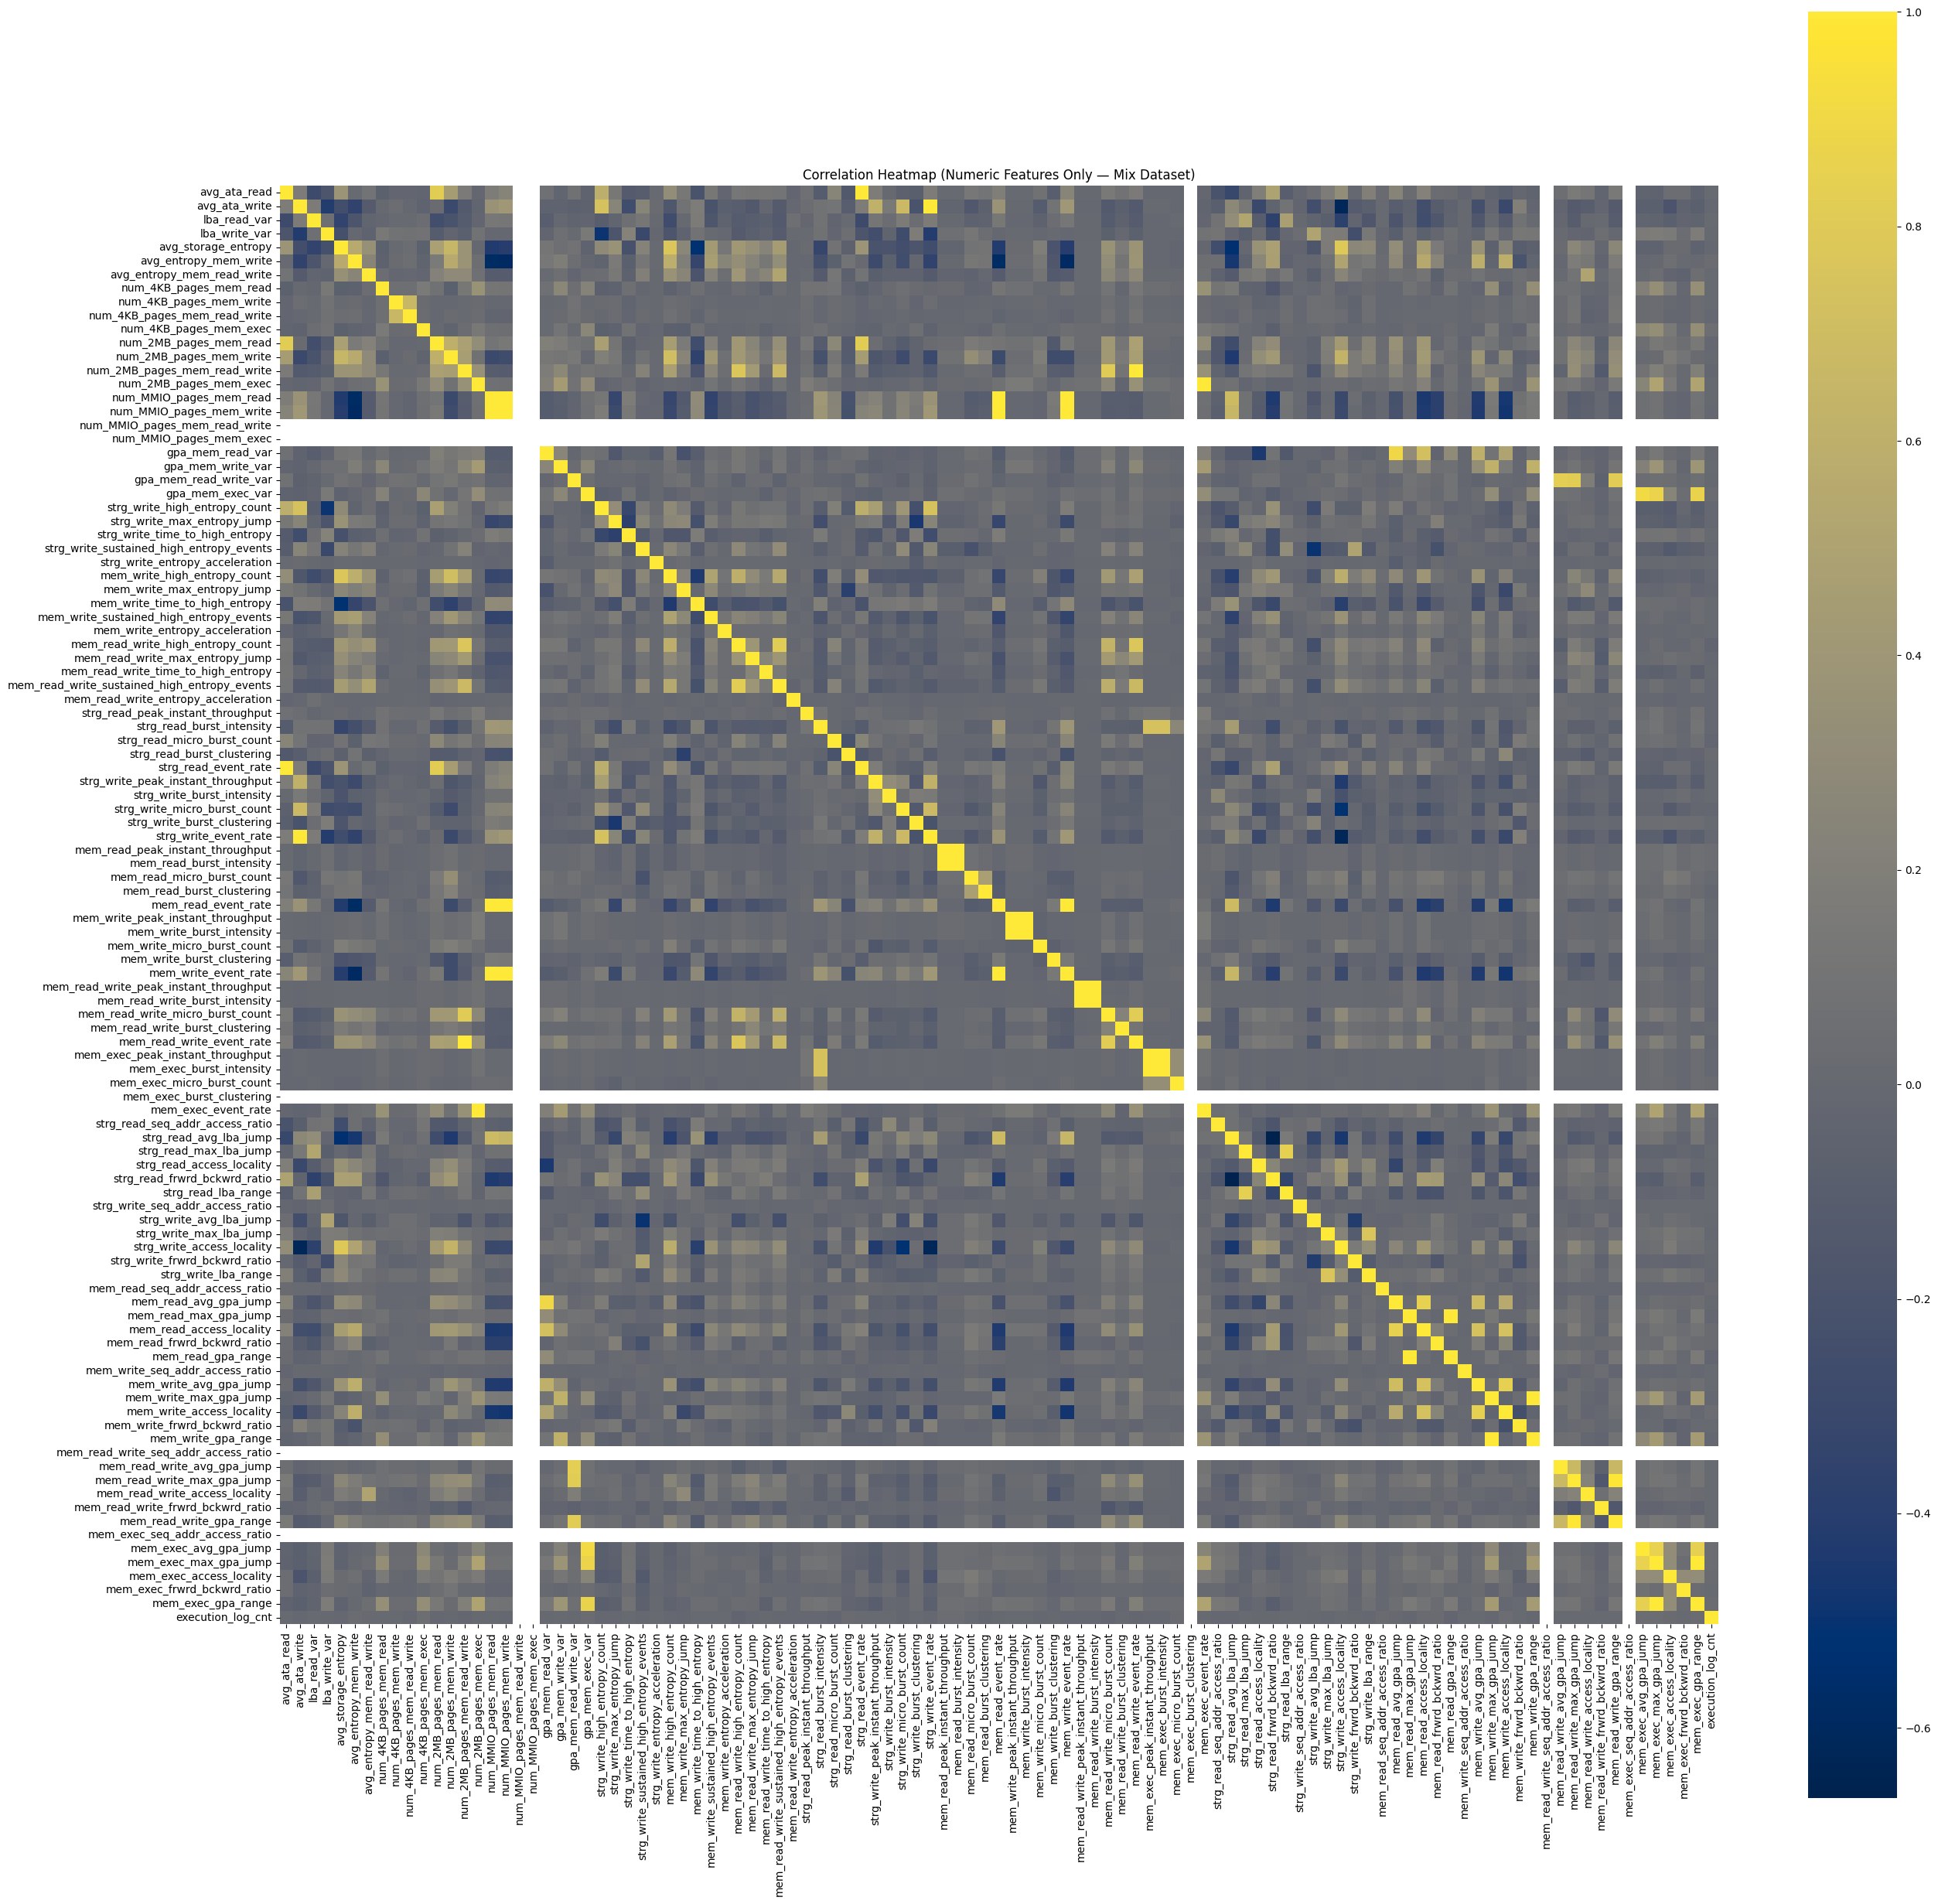

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(30, 30))
corr_matrix = mix_df[num_cols].corr()

sns.heatmap(
    corr_matrix,
    cmap="cividis",
    square=True,
    cbar=True,
    xticklabels=True,
    yticklabels=True
)

plt.title("Correlation Heatmap (Numeric Features Only — Mix Dataset)")
plt.show()

In [ ]:
model_df = mix_df[num_cols]
no_var_cols = model_df.columns[model_df.var() == 0]

In [ ]:
no_var_cols

Index(['num_MMIO_pages_mem_read_write', 'num_MMIO_pages_mem_exec',
       'mem_exec_burst_clustering', 'mem_read_write_seq_addr_access_ratio',
       'mem_exec_seq_addr_access_ratio'],
      dtype='object')

In [ ]:
model_df = model_df.drop(columns=no_var_cols)

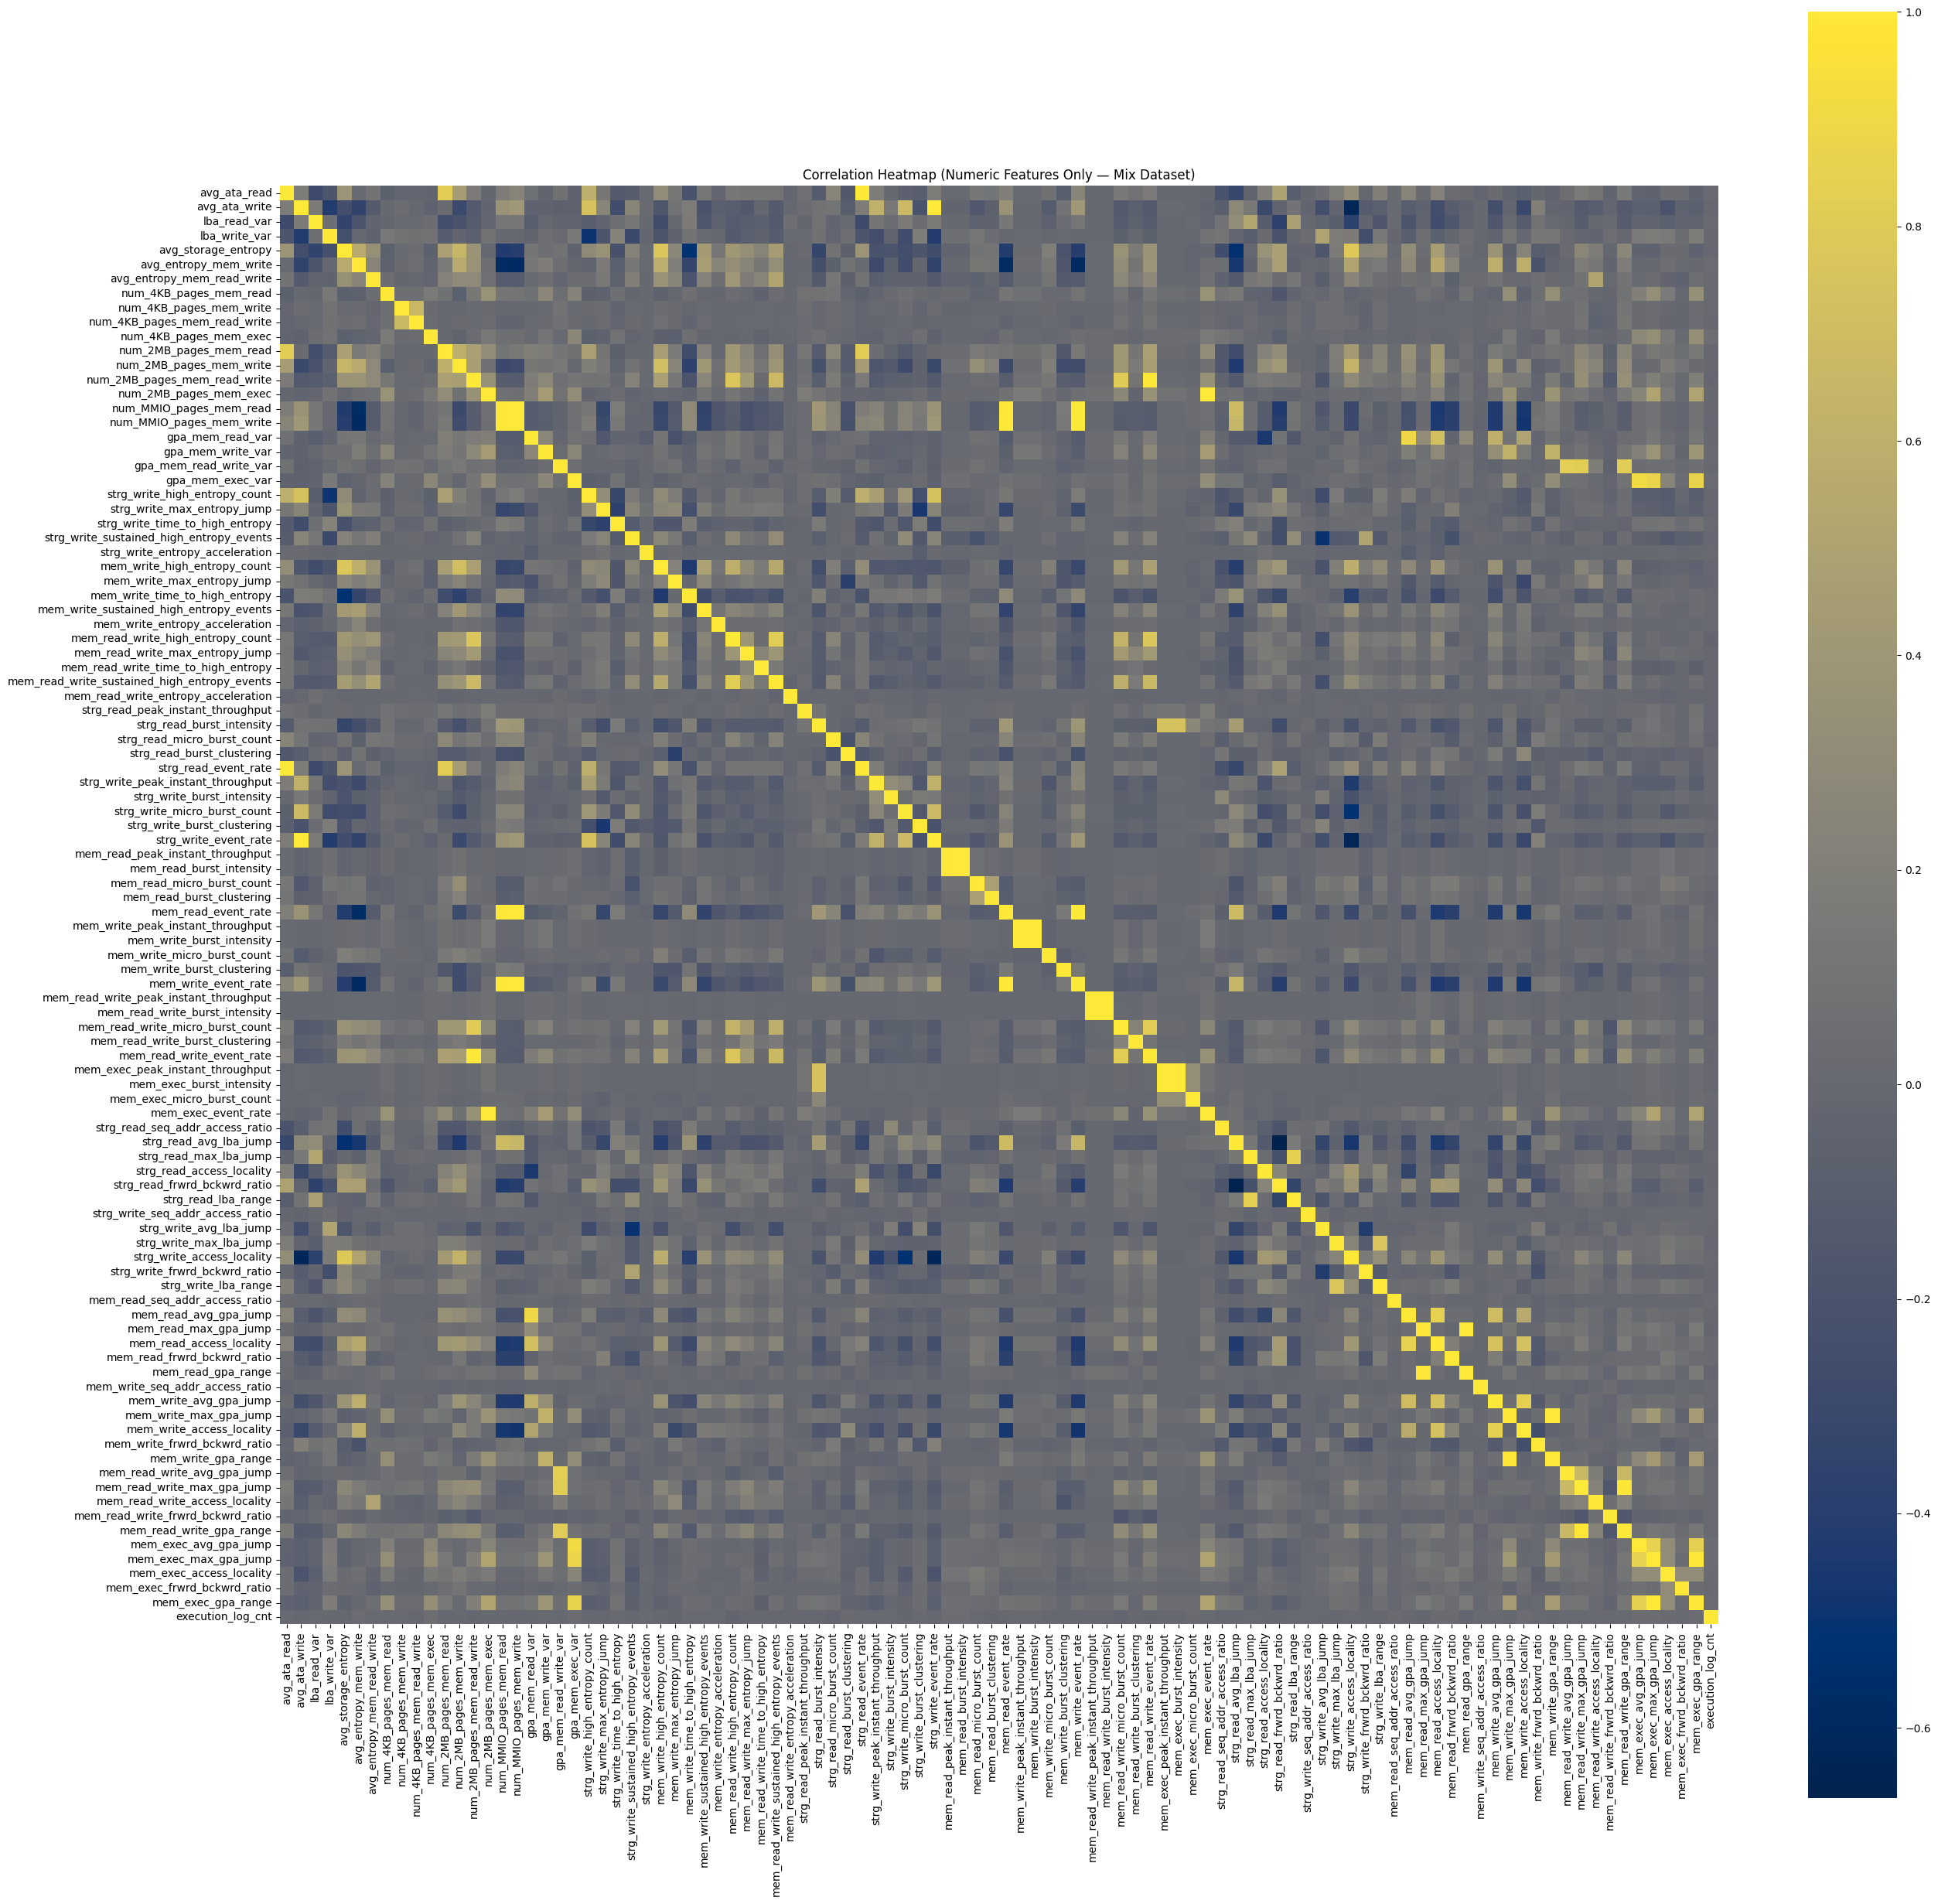

In [ ]:
plt.figure(figsize=(30, 30))
corr_matrix = model_df.corr()

sns.heatmap(
    corr_matrix,
    cmap="cividis",
    square=True,
    cbar=True,
    xticklabels=True,
    yticklabels=True
)

plt.title("Correlation Heatmap (Numeric Features Only — Mix Dataset)")
plt.show()

In [ ]:
import numpy as np

corr_matrix = model_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.9)]

model_df_reduced = model_df.drop(columns=high_corr_cols)

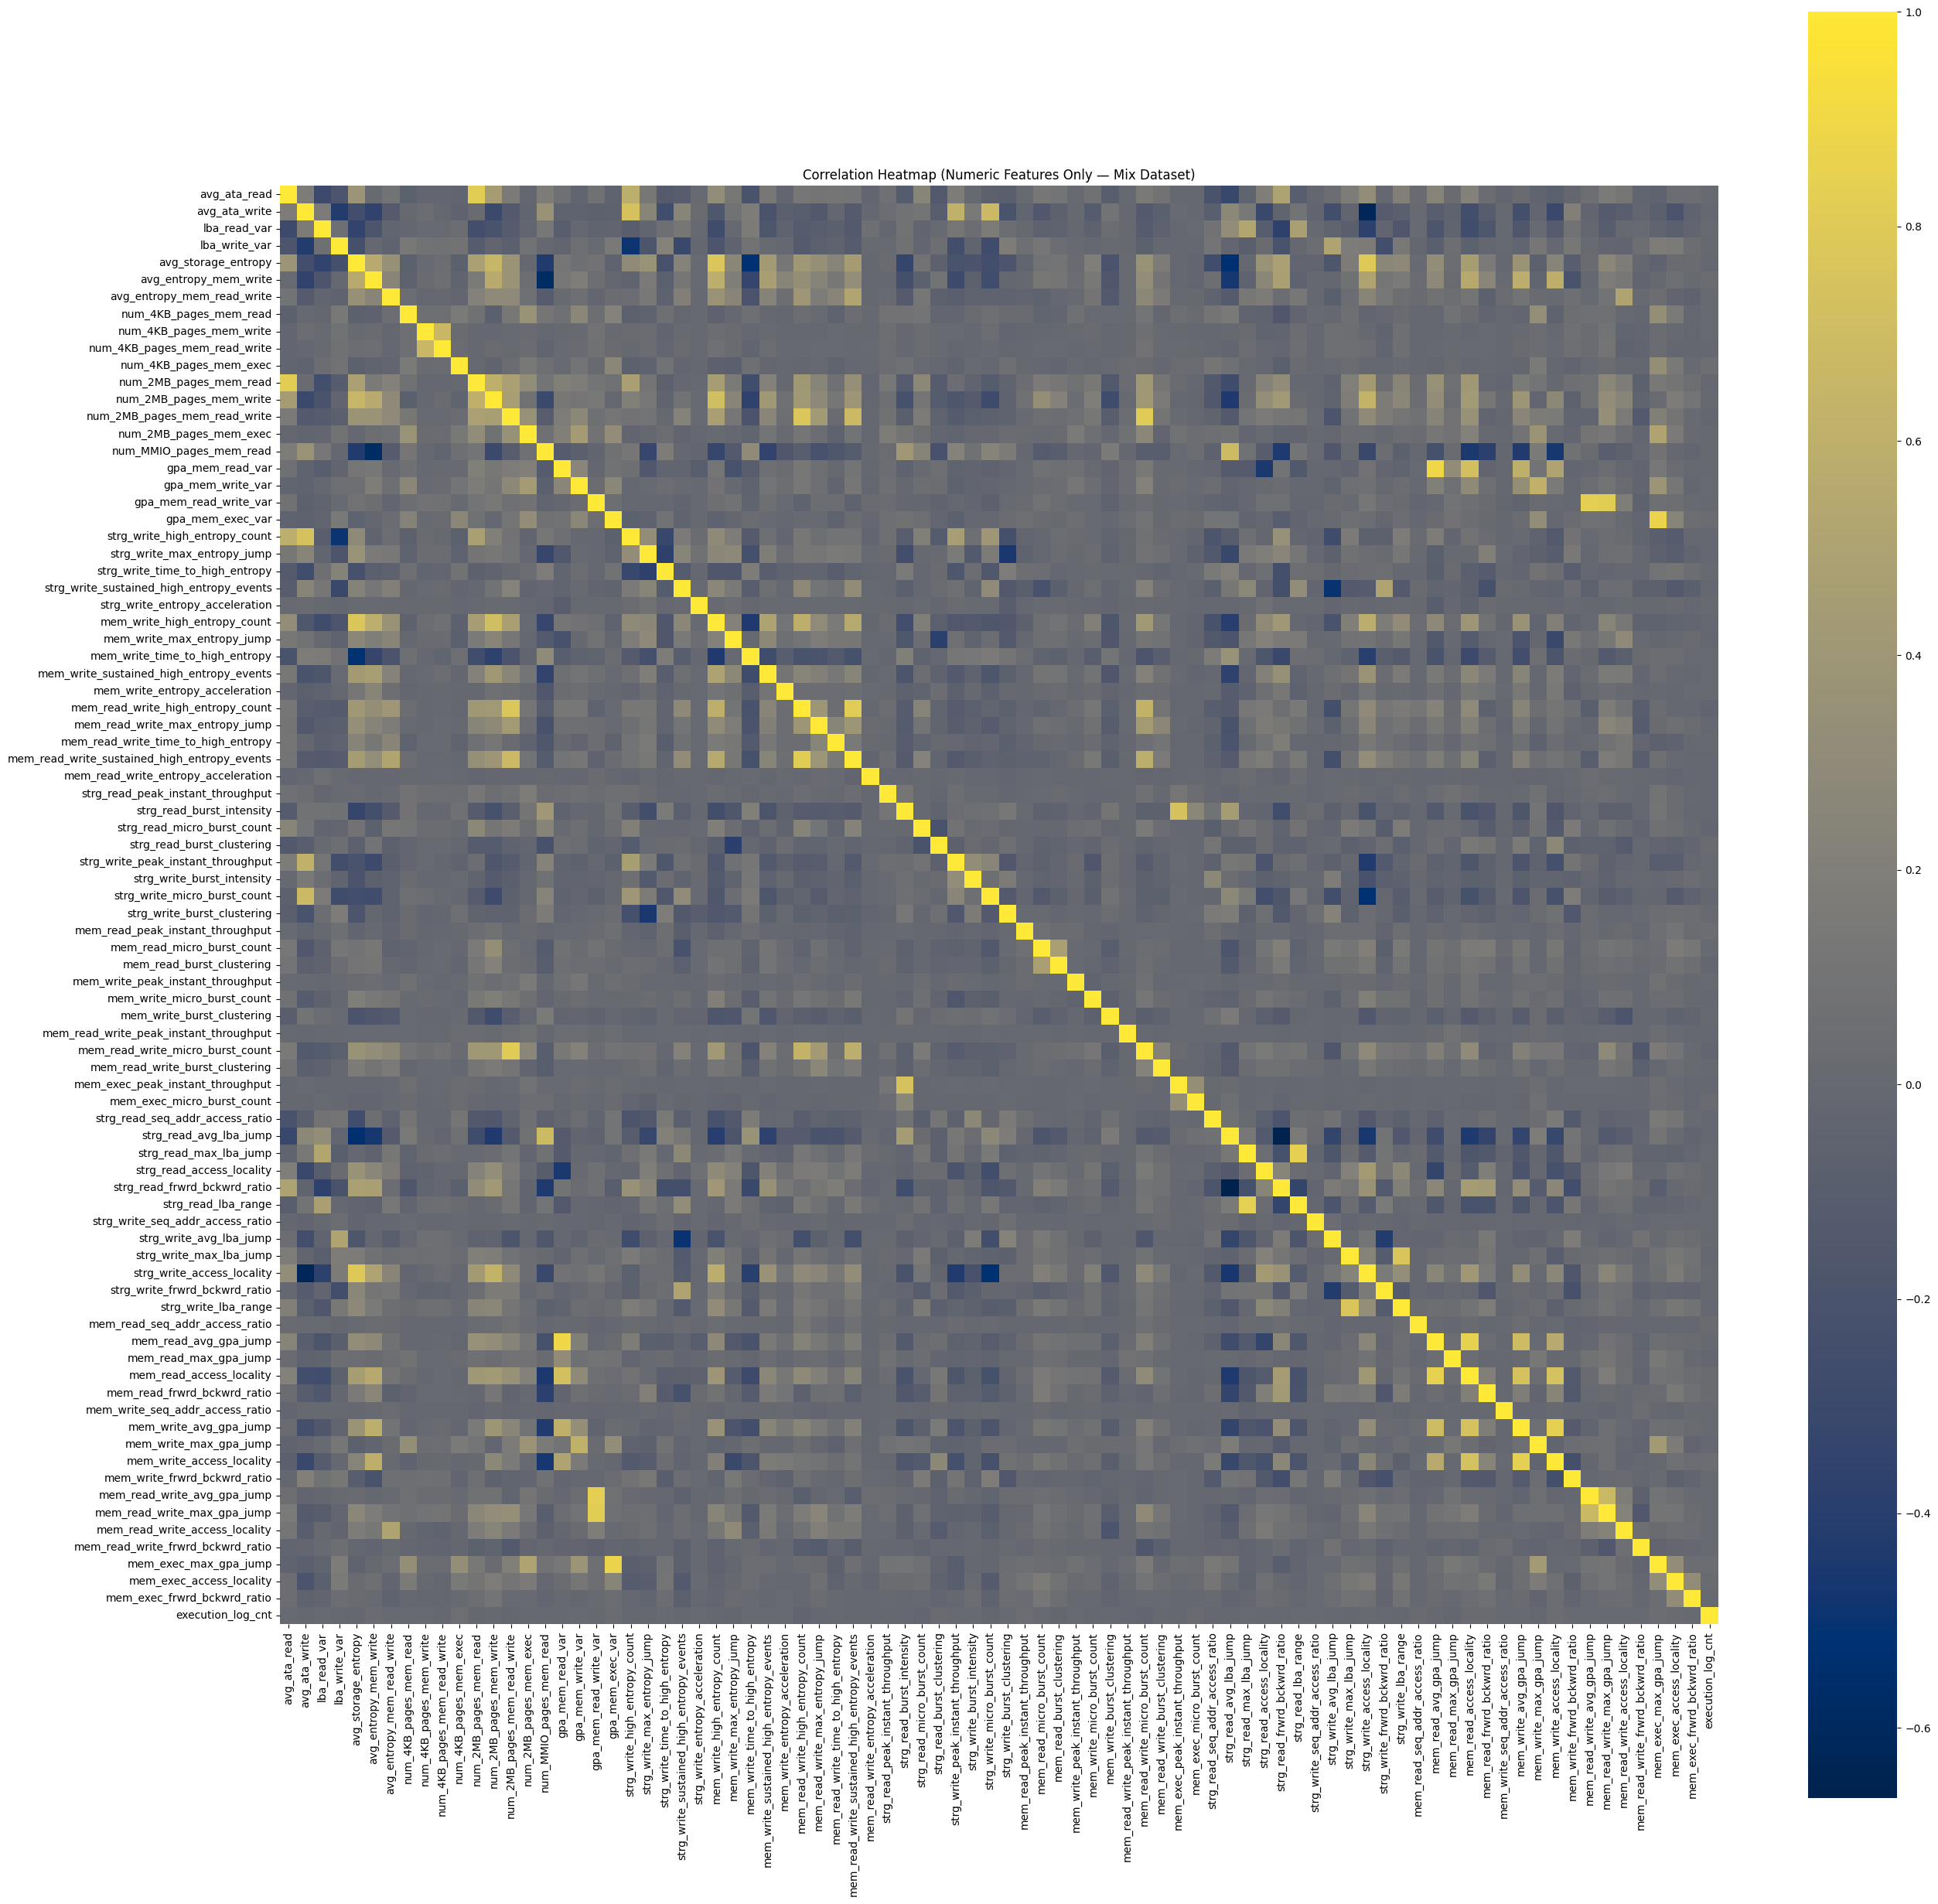

In [ ]:
plt.figure(figsize=(30, 30))
corr_matrix = model_df_reduced.corr()

sns.heatmap(
    corr_matrix,
    cmap="cividis",
    square=True,
    cbar=True,
    xticklabels=True,
    yticklabels=True
)

plt.title("Correlation Heatmap (Numeric Features Only — Mix Dataset)")
plt.show()

In [ ]:
dropped_cols = list(set(model_df.columns) - set(model_df_reduced.columns))
dropped_cols

['mem_write_burst_intensity',
 'mem_write_gpa_range',
 'mem_read_write_event_rate',
 'strg_write_event_rate',
 'mem_read_burst_intensity',
 'mem_read_write_burst_intensity',
 'mem_read_event_rate',
 'mem_exec_burst_intensity',
 'mem_exec_event_rate',
 'mem_exec_gpa_range',
 'mem_exec_avg_gpa_jump',
 'mem_read_gpa_range',
 'strg_read_event_rate',
 'mem_write_event_rate',
 'num_MMIO_pages_mem_write',
 'mem_read_write_gpa_range']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(model_df_reduced)

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=1
)

iso.fit(X_scaled)

anomaly_labels = iso.predict(X_scaled)

anomaly_scores = iso.decision_function(X_scaled)

mix_df['anomaly_label'] = anomaly_labels
mix_df['anomaly_score'] = anomaly_scores

mix_df[['operation', 'anomaly_label', 'anomaly_score']].head()


,operation,anomaly_label,anomaly_score
67754,AESCrypt_Conti,-1,-0.086520
67755,AESCrypt_Conti,-1,-0.003427
67756,AESCrypt_Conti,1,0.037754
67757,AESCrypt_Conti,1,0.053262
67758,AESCrypt_Conti,1,0.056476


In [ ]:
num_features = model_df_reduced.columns.tolist()

In [ ]:
op_dfs = {}

for op in uniq_ops:
    op_df = mix_df[mix_df['operation'] == op].copy()
    op_dfs[op] = op_df

In [ ]:
op_df.shape[0]

1791

In [ ]:
op_df.shape

(1791, 113)

In [ ]:
op = uniq_ops[0]

op_df = mix_df[mix_df['operation'] == op].copy()

In [ ]:
X = op_df[num_features]

X.shape

(1789, 84)

In [ ]:
X_scaled = scaler.transform(X)

X_scaled.shape

(1789, 84)

In [ ]:
iso2 = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=2
)

iso2.fit(X_scaled)

op_df['anomaly_label'] = iso2.predict(X_scaled)
op_df['anomaly_score'] = iso2.decision_function(X_scaled)

op_df[['anomaly_label', 'anomaly_score']].head()

,anomaly_label,anomaly_score
67754,-1,-0.142802
67755,-1,-0.061384
67756,-1,-0.004595
67757,1,0.027823
67758,1,0.039575


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
from sklearn.cluster import KMeans

k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=2, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

list(zip(k_values, inertias))

[(2, 22875.052054332446),
 (3, 9148.810747292086),
 (4, 5326.866750156074),
 (5, 3932.4619220575114),
 (6, 2615.160105813534),
 (7, 1733.427751448715),
 (8, 1453.2539614920688),
 (9, 1225.3466671076317),
 (10, 1062.9780533256671),
 (11, 875.5226157310982),
 (12, 768.2464485986053)]

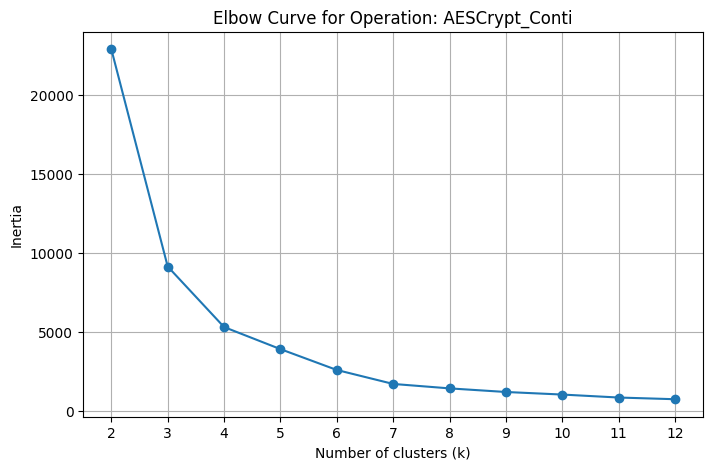

In [ ]:
import matplotlib.pyplot as plt

k_values = list(range(2, 13))
inertias = [
    22875.052054332446,
    9148.810747292086,
    5326.866750156074,
    3932.4619220575114,
    2615.160105813534,
    1733.427751448715,
    1453.2539614920688,
    1225.3466671076317,
    1062.9780533256671,
    875.5226157310982,
    768.2464485986053
]

plt.figure(figsize=(8,5))
plt.plot(k_values, inertias, marker='o')
plt.xticks(k_values)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title(f"Elbow Curve for Operation: {op}")
plt.grid(True)
plt.show()

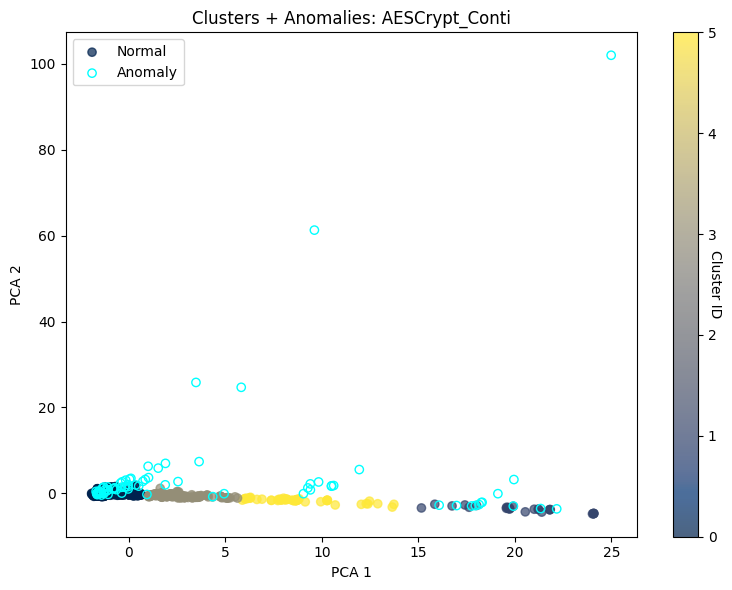

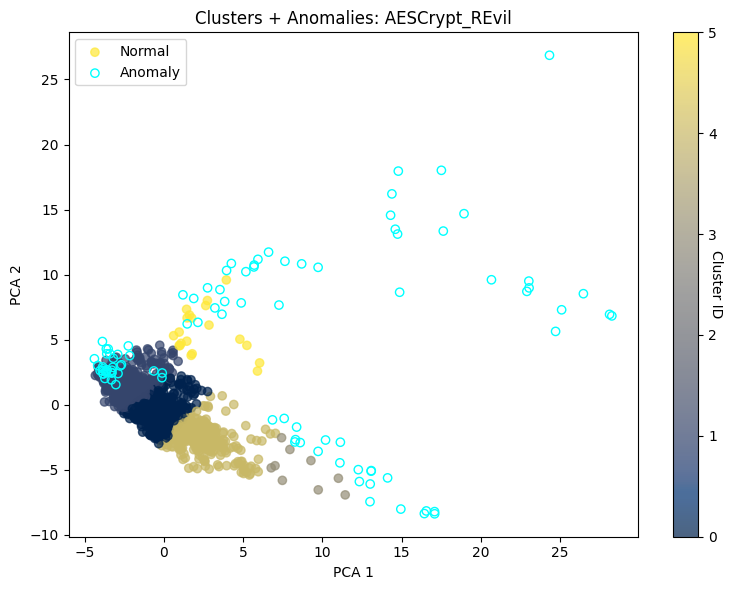

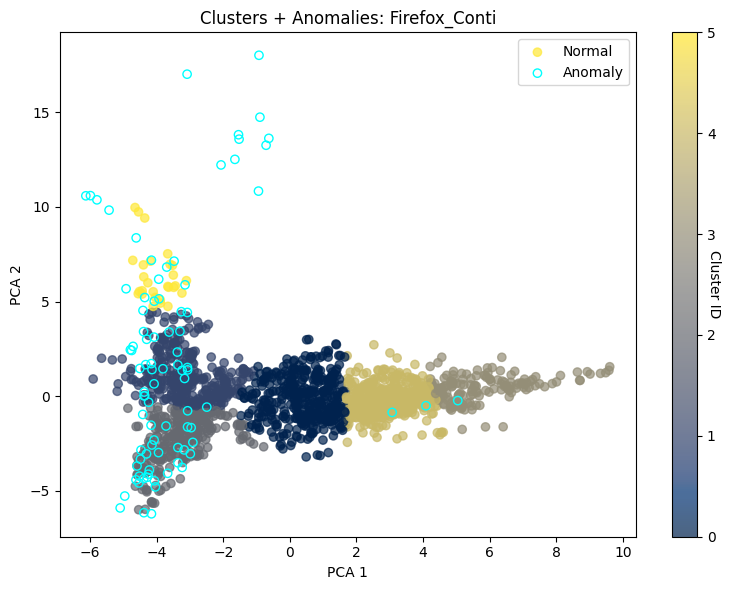

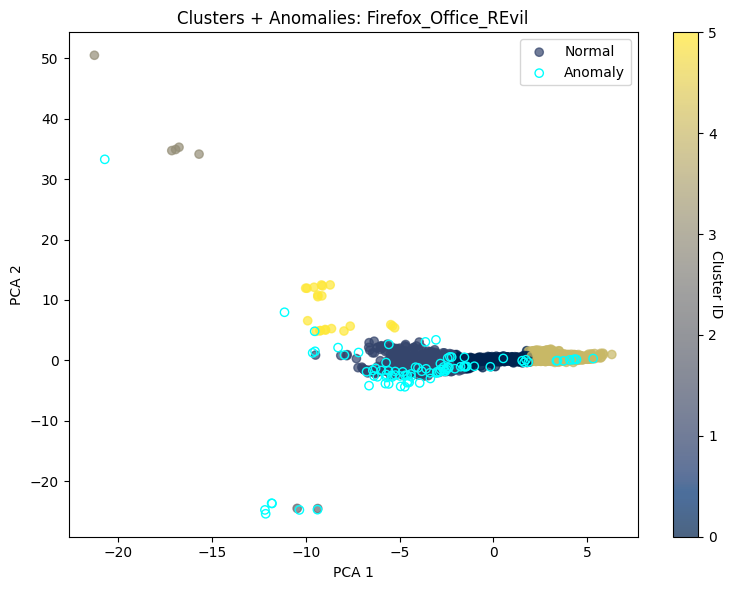

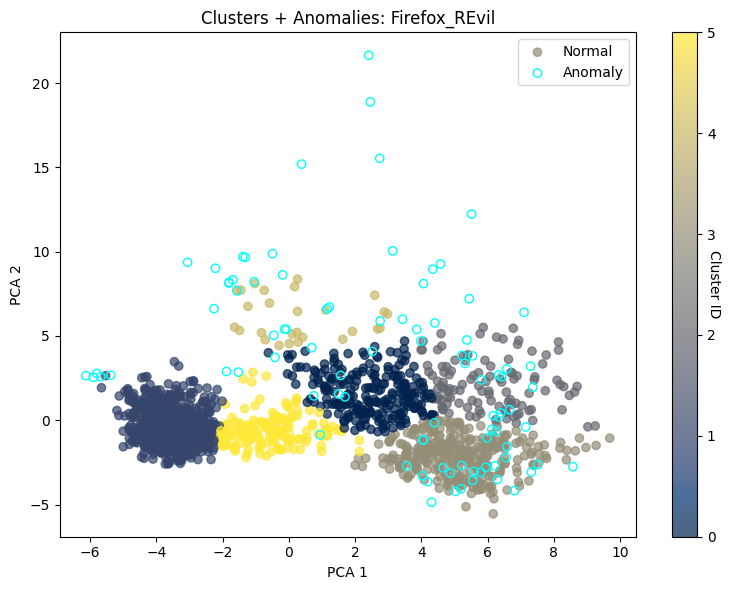

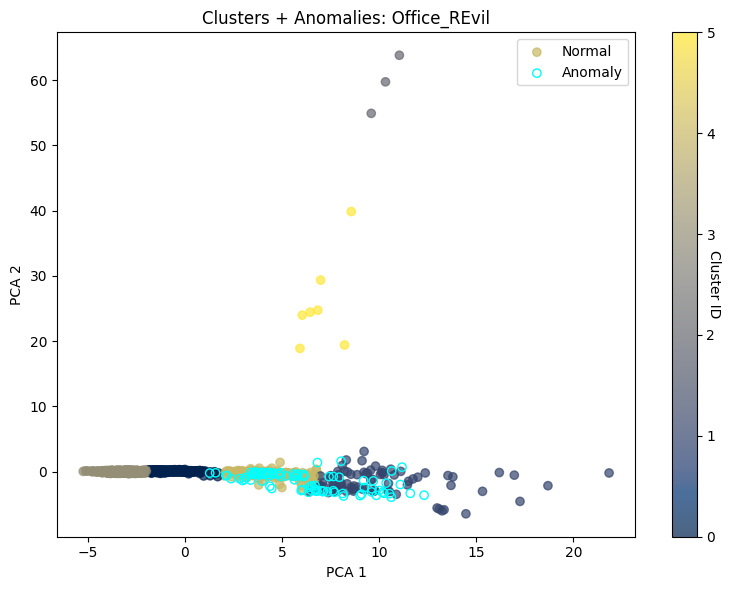

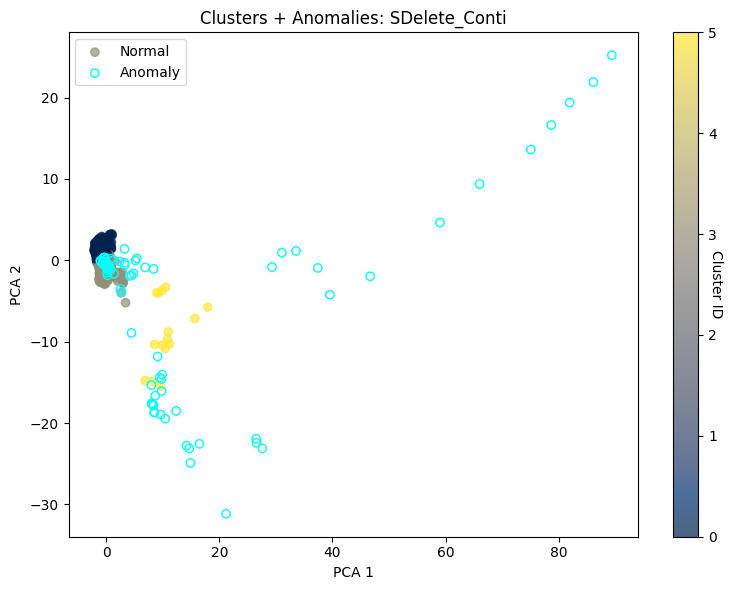

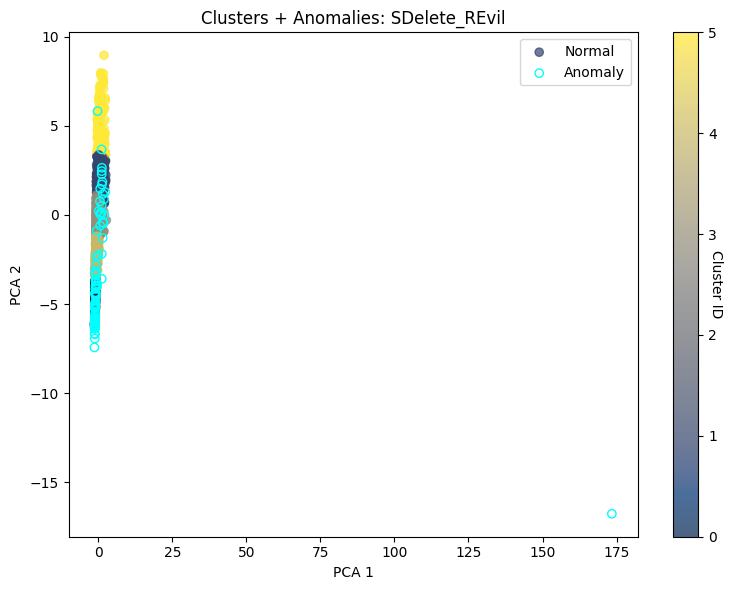

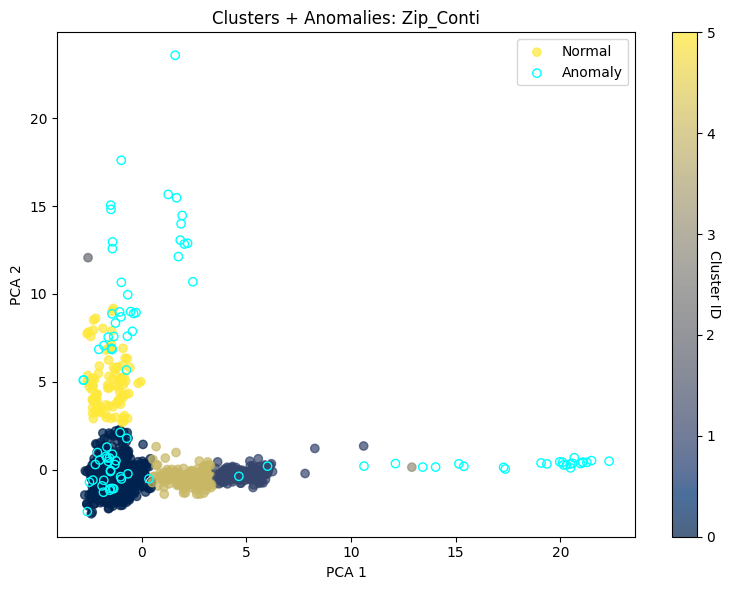

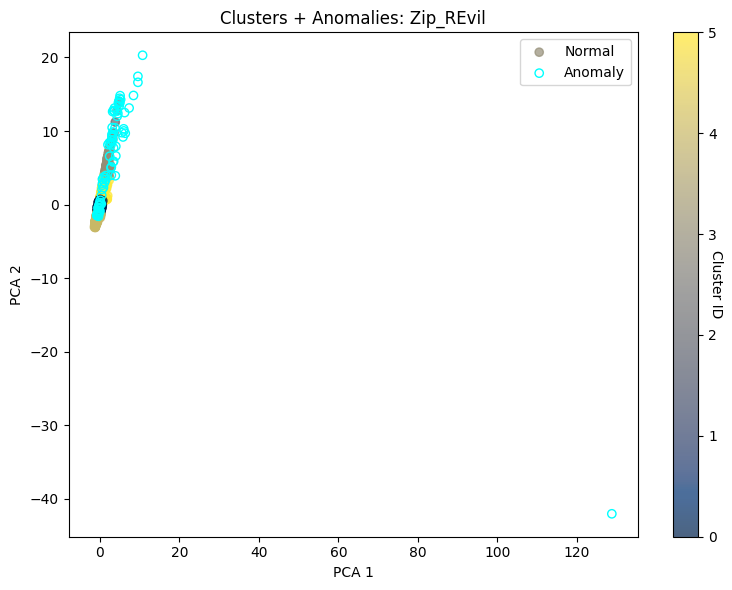

In [ ]:
for op in uniq_ops:

    op_df = mix_df[mix_df['operation'] == op].copy()

    X = op_df[num_features]
    X_scaled = scaler.transform(X)

    iso3 = IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=3
    )
    iso3.fit(X_scaled)
    op_df['anomaly_label'] = iso3.predict(X_scaled)
    op_df['anomaly_score'] = iso3.decision_function(X_scaled)

    pca = PCA(n_components=2, random_state=2)
    X_pca = pca.fit_transform(X_scaled)

    best_k = 6
    kmeans = KMeans(n_clusters=best_k, random_state=2, n_init=10)
    cluster_labels = kmeans.fit_predict(X_pca)

    plt.figure(figsize=(8, 6))

    normal_mask = (op_df['anomaly_label'] == 1)
    anomaly_mask = (op_df['anomaly_label'] == -1)

    sc = plt.scatter(
        X_pca[normal_mask, 0],
        X_pca[normal_mask, 1],
        c=cluster_labels[normal_mask],
        cmap="cividis",
        alpha=0.7,
        label="Normal"
    )

    plt.scatter(
        X_pca[anomaly_mask, 0],
        X_pca[anomaly_mask, 1],
        facecolors='none',
        edgecolors='#00ffff',
        label="Anomaly"
    )

    cbar = plt.colorbar(sc)
    cbar.set_label("Cluster ID", rotation=270)

    plt.title(f"Clusters + Anomalies: {op}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.tight_layout()
    plt.show()